In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/pcb-defect-dataset"

data.yaml  test  train	val


In [ ]:
!find "/content/drive/MyDrive" -iname "*.zip"

#updated path

/content/drive/MyDrive/Ship.zip
/content/drive/MyDrive/pcb-defect-dataset.zip
/content/drive/MyDrive/pcb-defect-dataset-20260425T163129Z-3-001.zip


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/pcb-defect-dataset.zip'
extract_path = '/content/pcb-dataset'

# Define a path within the extracted dataset to check for successful extraction
# For example, checking for the 'train' subdirectory
expected_train_dir = os.path.join(extract_path, "train")

# Only extract if the expected content (e.g., the 'train' directory) does not exist
if not os.path.exists(expected_train_dir):
    if os.path.exists(extract_path):
        print(f"Found partial or empty extraction path '{extract_path}'. Removing for clean extraction.")
        import shutil
        shutil.rmtree(extract_path) # Remove existing (potentially incomplete) directory

    print(f"Extracting dataset from {zip_path} to {extract_path}...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully!")
else:
    print("Expected dataset directories already exist. Skipping extraction.")

Extracting dataset from /content/drive/MyDrive/pcb-defect-dataset.zip to /content/pcb-dataset...
Dataset extracted successfully!


In [ ]:
# Correct dataset path

DATASET_PATH = extract_path

# Verify training images
!ls "$DATASET_PATH/train/images" | head

# Count total training images
import os

train_images_path = os.path.join(DATASET_PATH, "train", "images")
num_images = len(os.listdir(train_images_path))

print(f"Total Training Images: {num_images}")

light_01_missing_hole_01_1_600.jpg
light_01_missing_hole_01_2_600.jpg
light_01_missing_hole_02_1_600.jpg
light_01_missing_hole_03_1_600.jpg
light_01_missing_hole_04_1_600.jpg
light_01_missing_hole_04_2_600.jpg
light_01_missing_hole_06_1_600.jpg
light_01_missing_hole_06_2_600.jpg
light_01_missing_hole_08_1_600.jpg
light_01_missing_hole_08_3_600.jpg
Total Training Images: 8534


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load pre-trained MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model
base_model.trainable = False

# Build the classification model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#Strong Data Augmentation (parallel generator)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Use the successfully extracted dataset path that worked for Q3xpYhS9FGfk
# Assume 'extract_path' is defined in a previous cell, as it was used successfully in other cells.

DATASET_PATH = "/content/pcb-dataset" # This is the root where train/val/test are located

# Define paths for train and validation data, as the dataset is already split
TRAIN_DATA_DIR = os.path.join(DATASET_PATH, "train")
VAL_DATA_DIR = os.path.join(DATASET_PATH, "val")

# Verify that the directories exist
if not os.path.exists(TRAIN_DATA_DIR):
    raise FileNotFoundError(f"Training data directory not found: {TRAIN_DATA_DIR}. Please ensure the dataset is extracted by running earlier cells (e.g., those mounting Drive and unzipping the dataset).")
if not os.path.exists(VAL_DATA_DIR):
    raise FileNotFoundError(f"Validation data directory not found: {VAL_DATA_DIR}. Please ensure the dataset is extracted by running earlier cells (e.g., those mounting Drive and unzipping the dataset).")

# Generator for training data with strong augmentation
aug_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    shear_range=0.1
    # Removed validation_split as data is already split into train/val folders
)

# Generator for validation data (only rescaling, no augmentation)
aug_validation_datagen = ImageDataGenerator(
    rescale=1./255
)

aug_train_generator = aug_train_datagen.flow_from_directory(
    TRAIN_DATA_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True # Shuffle training data
)

aug_validation_generator = aug_validation_datagen.flow_from_directory(
    VAL_DATA_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False # Typically no shuffle for validation data
)

Found 8534 images belonging to 2 classes.
Found 1066 images belonging to 2 classes.


In [ ]:
TRAIN_PATH = "/content/drive/MyDrive/Dataset/pcb-defect-dataset/train"
VAL_PATH = "/content/drive/MyDrive/Dataset/pcb-defect-dataset/val"
TEST_PATH = "/content/drive/MyDrive/Dataset/pcb-defect-dataset/test"

Batch shape: (32, 224, 224, 3)


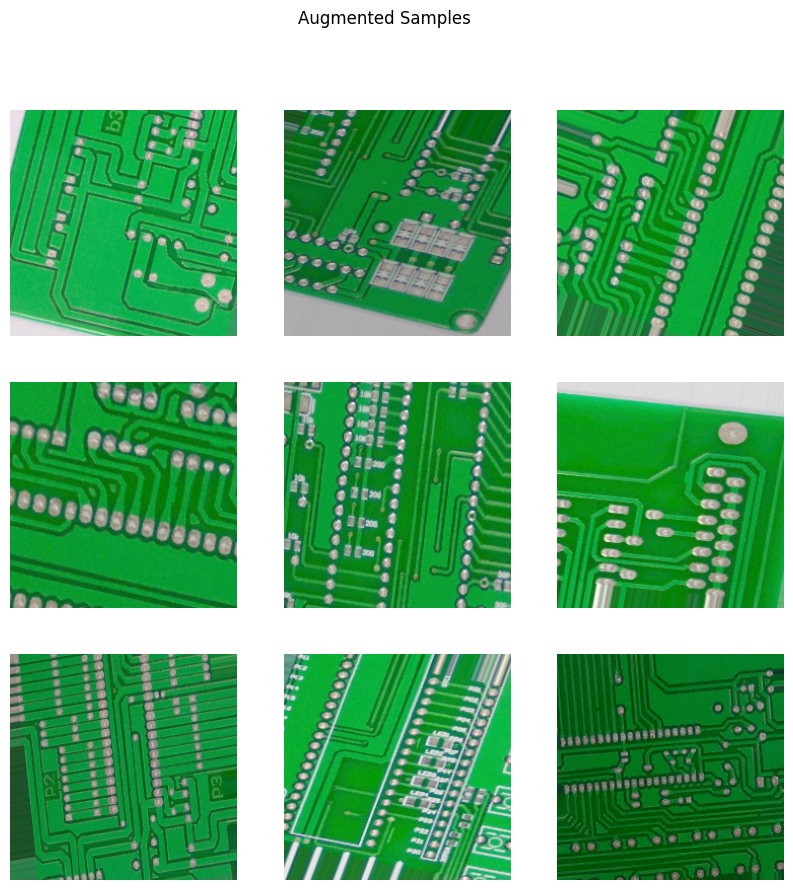

In [ ]:
# Visualize Augmentation (Corrected)

import matplotlib.pyplot as plt

images, labels = next(aug_train_generator)

print("Batch shape:", images.shape)

if len(images) == 0:
    print("No images found in generator. Check dataset folder structure.")
else:
    plt.figure(figsize=(10,10))

    num_images = min(9, len(images))

    for i in range(num_images):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i])
        plt.axis('off')

    plt.suptitle("Augmented Samples")
    plt.show()

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Train using Augmented Data (for better generalization)
history_aug = model.fit(
    aug_train_generator,
    validation_data=aug_validation_generator,
    epochs=10
)

Epoch 1/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 196s 663ms/step - accuracy: 1.0000 - loss: 0.0049 - val_accuracy: 1.0000 - val_loss: 3.3666e-04
Epoch 2/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 146s 547ms/step - accuracy: 1.0000 - loss: 1.5423e-04 - val_accuracy: 1.0000 - val_loss: 1.5006e-04
Epoch 3/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 144s 540ms/step - accuracy: 1.0000 - loss: 7.7907e-05 - val_accuracy: 1.0000 - val_loss: 8.5530e-05
Epoch 4/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 142s 532ms/step - accuracy: 1.0000 - loss: 4.7004e-05 - val_accuracy: 1.0000 - val_loss: 5.5746e-05
Epoch 5/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 144s 537ms/step - accuracy: 1.0000 - loss: 3.2398e-05 - val_accuracy: 1.0000 - val_loss: 3.8967e-05
Epoch 6/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 143s 535ms/step - accuracy: 1.0000 - loss: 2.2886e-05 - val_accuracy: 1.0000 - val_loss: 2.8836e-05
Epoch 7/10
267/267 ━━━━━━━━━━━━━━━━━━━━ 202s 537ms/step - accuracy: 1.0000 - loss: 1.7186e-05 - val_accuracy: 1.0000 - val_loss: 2.2025e-05
Epoch 8/10
267/267 ━━━━━

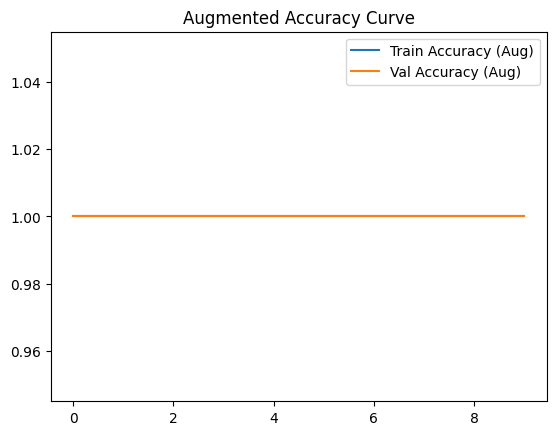

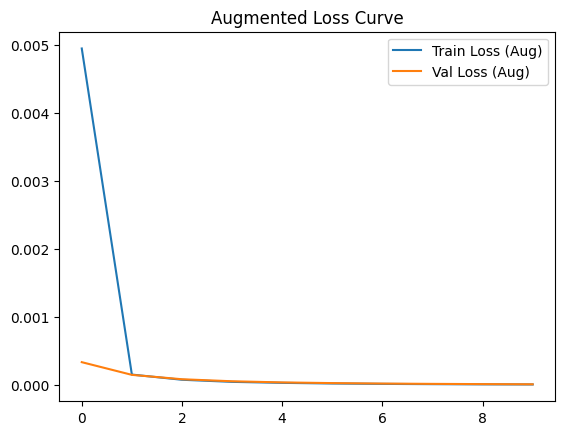

In [ ]:
#Plot Augmented Training Curves
plt.figure()
plt.plot(history_aug.history['accuracy'], label='Train Accuracy (Aug)')
plt.plot(history_aug.history['val_accuracy'], label='Val Accuracy (Aug)')
plt.legend()
plt.title("Augmented Accuracy Curve")
plt.show()

plt.figure()
plt.plot(history_aug.history['loss'], label='Train Loss (Aug)')
plt.plot(history_aug.history['val_loss'], label='Val Loss (Aug)')
plt.legend()
plt.title("Augmented Loss Curve")
plt.show()

In [ ]:
#Simple overfitting check
final_train_acc = history_aug.history['accuracy'][-1]
final_val_acc = history_aug.history['val_accuracy'][-1]

print("Final Train Accuracy:", final_train_acc)
print("Final Validation Accuracy:", final_val_acc)

if final_train_acc - final_val_acc > 0.1:
    print("Overfitting detected")
else:
    print("Model is generalizing well")

Final Train Accuracy: 1.0
Final Validation Accuracy: 1.0
Model is generalizing well


In [ ]:
base_model = model.get_layer('mobilenetv2_1.00_224')

In [ ]:
for layer in base_model.layers:
    print(layer.name)

input_layer
Conv1
bn_Conv1
Conv1_relu
expanded_conv_depthwise
expanded_conv_depthwise_BN
expanded_conv_depthwise_relu
expanded_conv_project
expanded_conv_project_BN
block_1_expand
block_1_expand_BN
block_1_expand_relu
block_1_pad
block_1_depthwise
block_1_depthwise_BN
block_1_depthwise_relu
block_1_project
block_1_project_BN
block_2_expand
block_2_expand_BN
block_2_expand_relu
block_2_depthwise
block_2_depthwise_BN
block_2_depthwise_relu
block_2_project
block_2_project_BN
block_2_add
block_3_expand
block_3_expand_BN
block_3_expand_relu
block_3_pad
block_3_depthwise
block_3_depthwise_BN
block_3_depthwise_relu
block_3_project
block_3_project_BN
block_4_expand
block_4_expand_BN
block_4_expand_relu
block_4_depthwise
block_4_depthwise_BN
block_4_depthwise_relu
block_4_project
block_4_project_BN
block_4_add
block_5_expand
block_5_expand_BN
block_5_expand_relu
block_5_depthwise
block_5_depthwise_BN
block_5_depthwise_relu
block_5_project
block_5_project_BN
block_5_add
block_6_expand
block_6_ex

In [ ]:
model.save("pcb_defect_model.h5")

In [ ]:
model = tf.keras.models.load_model("pcb_defect_model.h5")

In [ ]:
last_conv_layer_name = "Conv_1"

In [ ]:
model.build(input_shape=(None, 224, 224, 3))

In [ ]:
inputs = tf.keras.Input(shape=(224,224,3))
x = base_model(inputs)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)

# Compile the model after re-defining its structure
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
for layer in reversed(base_model.layers):
    if 'conv' in layer.name:
        print(layer.name)
        break

expanded_conv_project_BN


In [ ]:
base_model = model.get_layer('mobilenetv2_1.00_224')
last_conv_layer = base_model.get_layer(last_conv_layer_name)

print(model.input)
print(model.output)
print(last_conv_layer.output)

<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_487>
<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_490>
<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_151>


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def preprocess_image(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    return img_array

In [ ]:

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Ensure the model is built (if not already, e.g., after loading)
    if not model.built:
        model.build((None, 224, 224, 3)) # Build with example input shape

    # Convert the input image array to a TensorFlow tensor
    img_tensor_for_gradcam = tf.convert_to_tensor(img_array, dtype=tf.float32)

    try:
        # Get the MobileNetV2 layer from the main Sequential model
        base_model_extractor = model.get_layer('mobilenetv2_1.00_224')
    except ValueError:
        print("Error: MobileNetV2 layer with name 'mobilenetv2_1.00_224' not found in the model.")
        return np.zeros((7, 7))

    # Define a new input tensor for the Grad-CAM specific functional model
    grad_cam_input = tf.keras.Input(shape=(224, 224, 3))

    # Pass the new input through the base model extractor to get its output
    x_features = base_model_extractor(grad_cam_input)

    # The target convolutional layer output for Grad-CAM is `x_features` itself,
    # as base_model_extractor already represents the feature extractor up to 'Conv_1'
    target_conv_layer_output = x_features

    # Create *new* instances of the classification head layers.
    # This avoids potential graph conflicts when reusing layers from the original model.
    x_pool = tf.keras.layers.GlobalAveragePooling2D()(x_features)
    predictions = tf.keras.layers.Dense(1, activation='sigmoid')(x_pool)

    # Create the Grad-CAM functional model with the explicit input and both outputs
    grad_model = tf.keras.Model(
        inputs=grad_cam_input,
        outputs=[target_conv_layer_output, predictions]
    )

    with tf.GradientTape() as tape:
        # Pass the preprocessed image array through the newly constructed grad_model
        # The output order will be: [last_conv_layer_output, predictions]
        last_conv_layer_output, predictions = grad_model(img_tensor_for_gradcam)

        # Explicitly watch last_conv_layer_output for gradients
        tape.watch(last_conv_layer_output)

        # For binary classification, we want gradients with respect to the positive class score.
        loss = predictions[:, 0] # Assuming index 0 corresponds to the positive class

    # Compute gradients of the loss with respect to the output of the last conv layer.
    grads = tape.gradient(loss, last_conv_layer_output)

    if grads is None:
        print("Error: Gradients are None. This indicates a problem in tracing the gradient path.")
        print(f"Predictions shape: {predictions.shape}, Loss calculation: {loss.numpy()}")
        print(f"last_conv_layer_output shape: {last_conv_layer_output.shape}")
        # Fallback for when gradients are None, return an empty heatmap
        if last_conv_layer_output.shape.rank == 4:
            return np.zeros((last_conv_layer_output.shape[1], last_conv_layer_output.shape[2]))
        else:
            # If output shape is unexpected, return a 7x7 empty array as a generic fallback
            return np.zeros((7,7))

    # Pool the gradients over all the channels to get a single vector per filter.
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the feature map array by "how important" this channel is
    # with regard to the top predicted class.
    last_conv_layer_output_val = last_conv_layer_output[0] # Get the feature map for the first (and only) image in batch
    heatmap = last_conv_layer_output_val @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize the heatmap to [0, 1].
    heatmap = tf.maximum(heatmap, 0) # Apply ReLU to heatmap
    max_heatmap = tf.reduce_max(heatmap)
    if max_heatmap == 0:
        print("Warning: Max heatmap value is zero, cannot normalize. Returning an empty heatmap.")
        return np.zeros(heatmap.shape)
    heatmap = heatmap / (max_heatmap + tf.keras.backend.epsilon()) # Add epsilon for numerical stability

    return heatmap.numpy()

In [ ]:
def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap) # Scale to 0-255

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET) # Apply jet colormap

    # Superimpose the heatmap on the original image
    superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)

    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

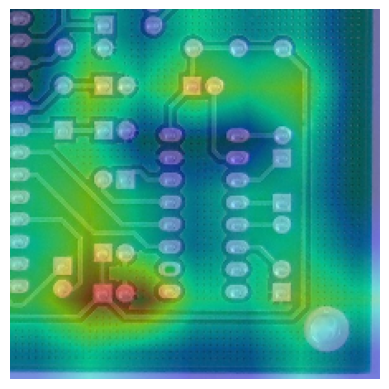

In [ ]:
# Correcting the image path to use an actual image from the dataset
# The actual extraction path is stored in 'extract_path'
DATASET_PATH = extract_path # Corrected to use the variable holding the successful extraction path
img_path = os.path.join(DATASET_PATH, "train", "images", "light_01_missing_hole_01_1_600.jpg")

img_array = preprocess_image(img_path)

heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name='Conv_1' # Use 'Conv_1' as identified from previous steps
)

display_gradcam(img_path, heatmap)

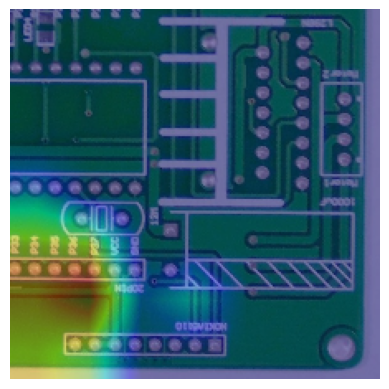

In [ ]:
DATASET_PATH = extract_path # Corrected to use the variable holding the successful extraction path
img_path = os.path.join(DATASET_PATH, "train", "images", "l_light_08_spur_02_4_600.jpg")

img_array = preprocess_image(img_path)

heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name='Conv_1' # Use 'Conv_1' as identified from previous steps
)

display_gradcam(img_path, heatmap)

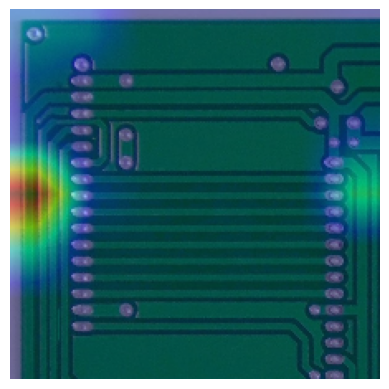

In [ ]:
DATASET_PATH = extract_path # Corrected to use the variable holding the successful extraction path
img_path = os.path.join(DATASET_PATH, "train", "images", "l_light_05_spurious_copper_08_1_600.jpg")

img_array = preprocess_image(img_path)

heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name='Conv_1' # Use 'Conv_1' as identified from previous steps
)

display_gradcam(img_path, heatmap)

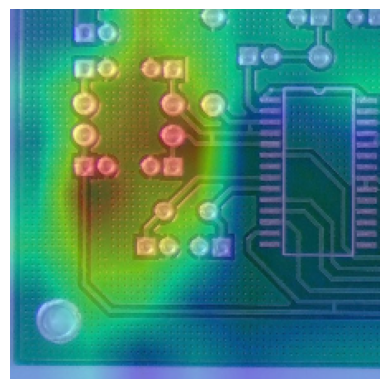

In [ ]:
DATASET_PATH = extract_path # Corrected to use the variable holding the successful extraction path
img_path = os.path.join(DATASET_PATH, "train", "images", "light_01_short_09_2_600.jpg")

img_array = preprocess_image(img_path)

heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name='Conv_1' # Use 'Conv_1' as identified from previous steps
)

display_gradcam(img_path, heatmap)

In [ ]:
model.save("pcb_defect_model.h5")

In [ ]:
model = tf.keras.models.load_model(
    "pcb_defect_model.h5",
    compile=False
)

In [ ]:
from google.colab.patches import cv2_imshow

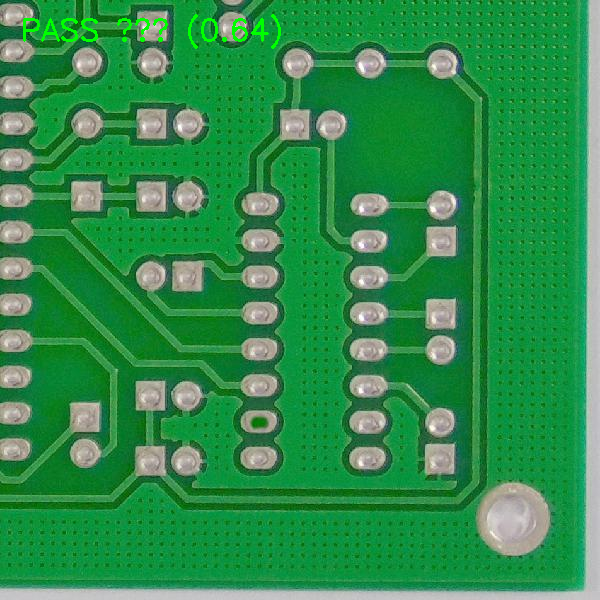

Prediction: PASS ✅
Confidence: 0.64


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from google.colab.patches import cv2_imshow # Import cv2_imshow for Colab

# -----------------------------------
# Load Trained Model
# -----------------------------------
model = tf.keras.models.load_model(
    "pcb_defect_model.h5",
    compile=False
)

IMG_SIZE = 224

# -----------------------------------
# Load Image
# -----------------------------------
# Corrected image path to an existing image from the dataset
# Using a known good image path from previous cells (e.g., from Grad-CAM visualization)
image_path = "/content/pcb-dataset/train/images/light_01_missing_hole_01_1_600.jpg"

image = cv2.imread(image_path)

# Check if image was loaded successfully
if image is None:
    print(f"Error: Could not load image from {image_path}. Please check the path.")
else:
    # Resize image
    img = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    # Preprocess image
    img_array = img.astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # -----------------------------------
    # Prediction
    # -----------------------------------
    prediction = model.predict(img_array, verbose=0)[0][0]

    # -----------------------------------
    # PASS / DEFECT Classification
    # -----------------------------------
    if prediction > 0.5:
        result = "DEFECT ❌"
        color = (0, 0, 255)   # Red
        confidence = prediction
    else:
        result = "PASS ✅"
        color = (0, 255, 0)   # Green
        confidence = 1 - prediction

    # -----------------------------------
    # Display Result
    # -----------------------------------
    # Need to create a copy of the original image for displaying text,
    # as 'image' might be used directly for showing later.
    display_image = image.copy()
    cv2.putText(
        display_image,
        f"{result} ({confidence:.2f})",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        color,
        2
    )

    # Show image using cv2_imshow for Colab compatibility
    cv2_imshow(display_image)

    # cv2.waitKey(0) and cv2.destroyAllWindows() are not needed with cv2_imshow in Colab

    # Print result in terminal
    print("Prediction:", result)
    print("Confidence:", round(float(confidence), 2))